Bezier curves:

C(u) = sum_{i=0 to n} B_{i,n}(u) * P_i

where B_{i,n}(u) are the Bernstein polynomials. This is an equivalent but more convenient form of a B-spline.
The difference with this to B-spline is that uses control points (whereas B-splines are typically defined as power series about the origin, less convenient form).

Bernstein polynomials are:
B_{i,n}(u) = n choose i * u^i * (1-u)^{n-i}

The third order Bezier curve then becomes..
C(u) = (1-u)^3 * P0 + 3 * u * (1-u)^2 * P1 + 3 * u^2 * (1-u) * P2 + u^3 * P3

Some examples are given below.

In [39]:
import numpy as np
import matplotlib.pyplot as plt
# import math
from scipy.special import comb


# define the method

def plot_bezier_curve(control_points, n_pts:int=30):
    N = control_points.shape[0] - 1

    u = np.linspace(0.0, 1.0, n_pts)
    x, y = np.zeros_like(u), np.zeros_like(u)
    for i in range(N+1):
        nchoose_k = comb(N, i, exact=True)
        # nchoose_k = math.comb(N, i)
        bernstein_poly = nchoose_k * u**i * (1.0-u)**(N-i)
        point = control_points[i]
        x += bernstein_poly * point[0]
        y += bernstein_poly * point[1]

    plt.plot(x, y, 'o-')

    # draw also the control polygon
    for i in range(N):
        p1, p2 = control_points[i], control_points[i+1]
        x = p1[0] * (1-u) + p2[0] * u
        y = p1[1] * (1-u) + p2[1] * u
        plt.plot([p1[0], p2[0]], [p1[1], p2[1]], 'ko--')

    plt.show()


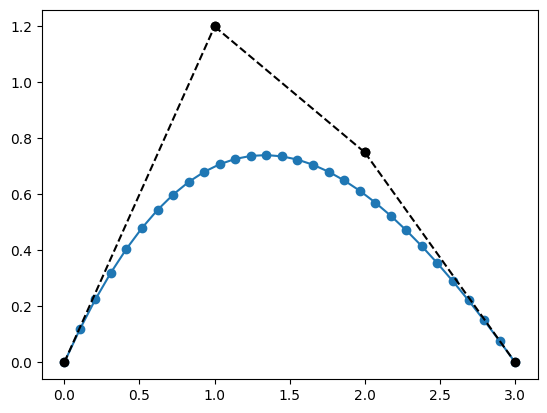

In [40]:

# now demonstrate a bezier curve

plot_bezier_curve(
    control_points=np.array([
        [0.0]*2,
        [1.0, 1.2],
        [2.0, 0.75],
        [3.0, 0.0]
    ]), 
    n_pts=30
)

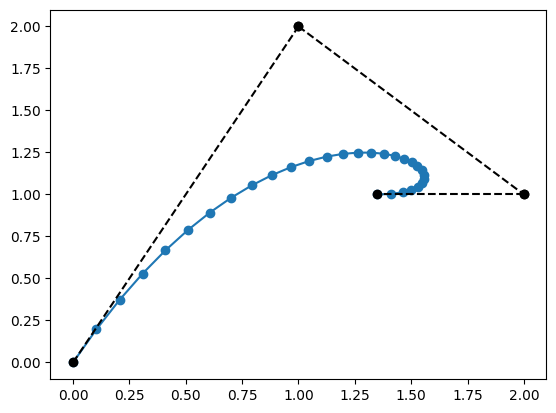

In [41]:
# plot another bezier curve

plot_bezier_curve(
    control_points=np.array([
         [0.0]*2,
        [1.0, 2.0],
        [2.0, 1.0],
        [1.35, 1.0]
    ]), 
    n_pts=30
)

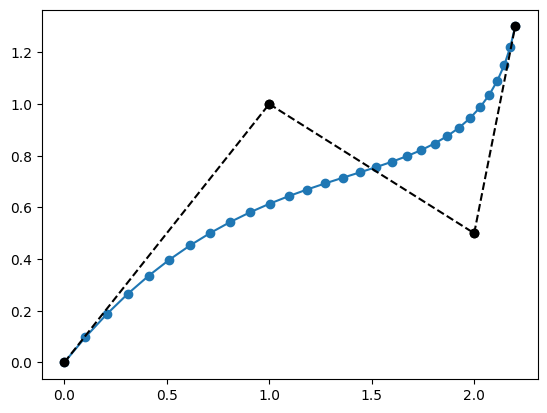

In [42]:
# plot another bezier curve

plot_bezier_curve(
    control_points=np.array([
        [0.0]*2,
        [1.0, 1.0],
        [2.0, 0.5],
        [2.2, 1.3]
    ]), 
    n_pts=30
)

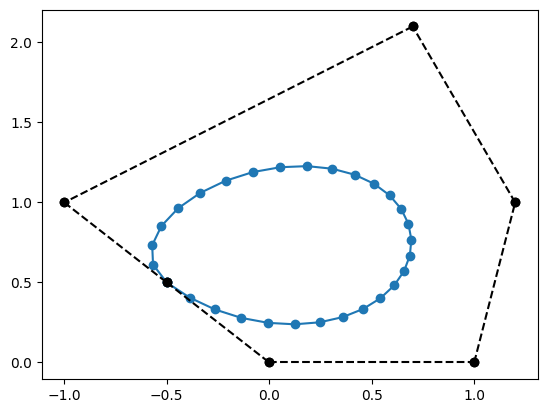

In [48]:
# plot another bezier curve

plot_bezier_curve(
    control_points=np.array([
        [-0.5, 0.5],
        [0.0]*2,
        [1.0, 0.0],
        [1.2, 1.0],
        [0.7, 2.1],
        [-1.0, 1.0],
        [-0.5, 0.5],
        # [0.0, 0.0]
        # [0.0, 0.0]
    ]), 
    n_pts=30
)